In [25]:
import h5py
import os
import datetime
import tqdm
os.getcwd()
import sys
sys.path.insert(0, os.path.abspath("CT_MPS"))

from postprocessing_func import *

In [2]:
# List all files in the directory "hdf5_data/p_ctrl0.4_haining/"
dir_path = "hdf5_data/p_ctrl0.4_haining/"
files = os.listdir(dir_path)
files_full_path = [os.path.join(dir_path, f) for f in files]


In [3]:
# combined_sv_filename = f"hdf5_data_combined/sv_combined_p_ctrl0.4_{datetime.datetime.now().strftime('%Y-%m-%d')}.h5"
combined_sv_filename = "hdf5_data_combined/sv_combined_p_ctrl0.4_2025-11-08.h5"
print(combined_sv_filename)

hdf5_data_combined/sv_combined_p_ctrl0.4_2025-11-08.h5


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import tqdm

data_dict = {}
with h5py.File(combined_sv_filename, 'r') as f:
    keys = list(f.keys())
    for key in tqdm.tqdm(keys):
        proj, L = f[key].attrs['p_proj'], f[key].attrs['L']
        sv_arr = f[key][:]
        if (proj, L) not in data_dict:
            data_dict[(proj, L)] = [sv_arr]
        else:
            data_dict[(proj, L)].append(sv_arr)


100%|██████████| 394709/394709 [05:05<00:00, 1291.55it/s]


In [23]:
def mean_med_diff(arr):
    return abs(np.mean(arr) - np.median(arr))

def binder_cumulant_centered(data):
    """Binder cumulant for fluctuations δM = M - <M>"""
    data = np.array(data)
    delta_M = data - np.mean(data)
    m2 = np.mean(delta_M**2)
    m4 = np.mean(delta_M**4)
    U = 1 - m4 / (3 * m2**2)
    return U

In [26]:
df_s0 = df_obs_from_sv_arr(data_dict, s0, binder_cumulant_centered)
df_corrlen = df_obs_from_sv_arr(data_dict, corr_len, binder_cumulant_centered)

/tmp/ipykernel_35560/2302527253.py:10: RuntimeWarning: invalid value encountered in scalar divide
  U = 1 - m4 / (3 * m2**2)
/home/ty296/.conda/envs/scicomp/lib/python3.8/site-packages/scipy/stats/_stats_mstats_common.py:181: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm
/home/ty296/.conda/envs/scicomp/lib/python3.8/site-packages/scipy/stats/_stats_mstats_common.py:195: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/home/ty296/.conda/envs/scicomp/lib/python3.8/site-packages/scipy/stats/_stats_mstats_common.py:198: RuntimeWarning: invalid value encountered in scalar divide
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)
/tmp/ipykernel_35560/2302527253.py:10: RuntimeWarning: invalid value encountered in scalar divide
  U = 1 - m4 / (3 * m2**2)


/home/ty296/.conda/envs/scicomp/lib/python3.8/site-packages/scipy/stats/_stats_mstats_common.py:181: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm
/home/ty296/.conda/envs/scicomp/lib/python3.8/site-packages/scipy/stats/_stats_mstats_common.py:195: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/home/ty296/.conda/envs/scicomp/lib/python3.8/site-packages/scipy/stats/_stats_mstats_common.py:198: RuntimeWarning: invalid value encountered in scalar divide
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)


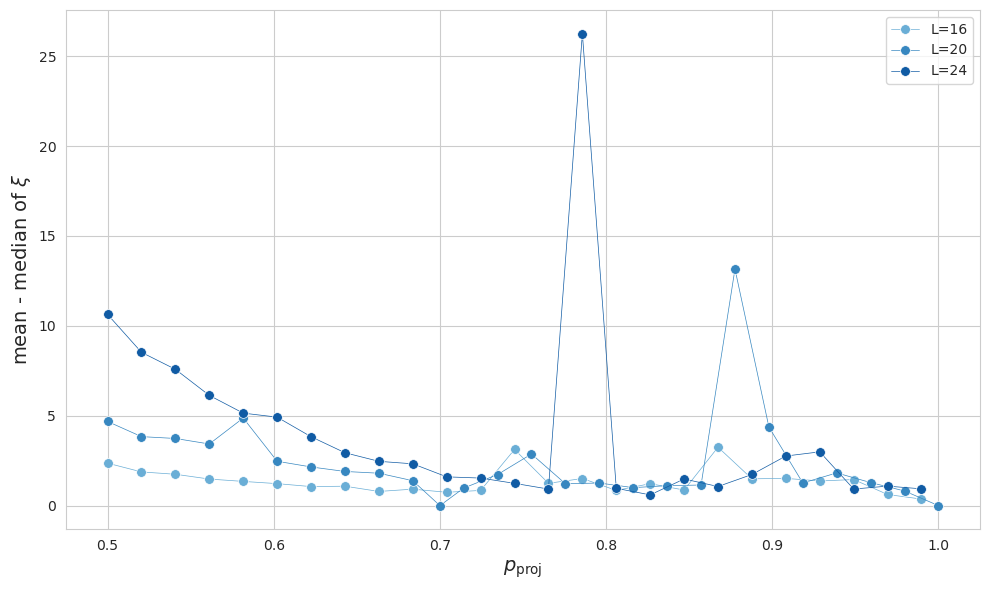

In [27]:
df_mmd_corrlen = df_obs_from_sv_arr(data_dict, corr_len, mean_med_diff)
plot_ensemble_metric(df_mmd_corrlen, r'$p_{\mathrm{proj}}$', r'mean - median of $\xi$', L_list=[16, 20, 24])

In [ ]:
df_mean_med_diff_s0 = df_obs_from_sv_arr(data_dict, s0, mean_med_diff)

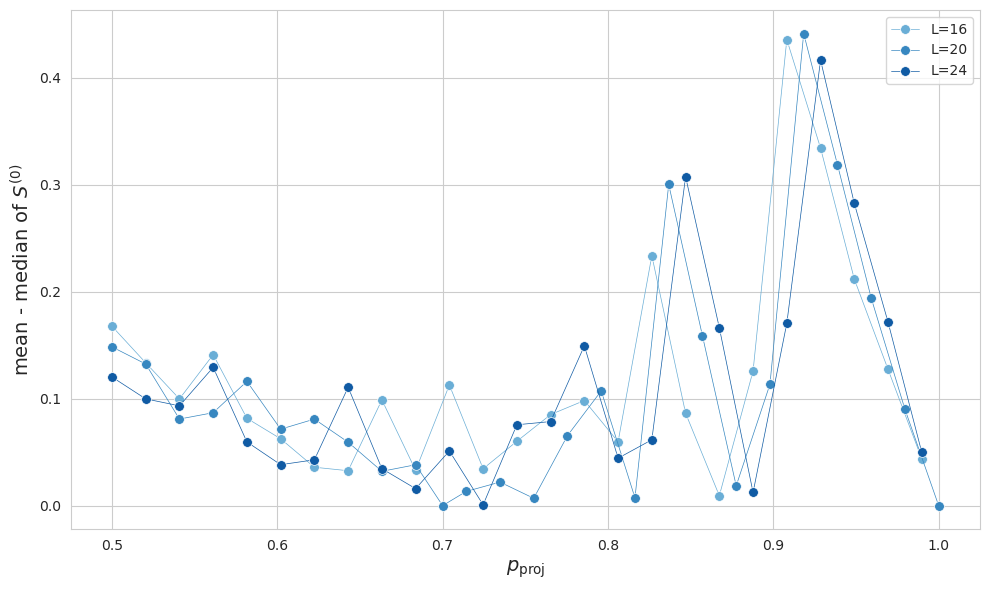

In [ ]:
plot_ensemble_metric(df_mean_med_diff_s0, r'$p_{\mathrm{proj}}$', r'mean - median of $S^{(0)}$', L_list=[16, 20, 24])

/home/ty296/.conda/envs/scicomp/lib/python3.8/site-packages/scipy/stats/_stats_mstats_common.py:181: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm
/home/ty296/.conda/envs/scicomp/lib/python3.8/site-packages/scipy/stats/_stats_mstats_common.py:195: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/home/ty296/.conda/envs/scicomp/lib/python3.8/site-packages/scipy/stats/_stats_mstats_common.py:198: RuntimeWarning: invalid value encountered in scalar divide
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)
/scratch/ty296/CT_MPS/postprocessing_func.py:39: RuntimeWarning: invalid value encountered in scalar divide
  U = 1 - m4 / (3 * m2**2)


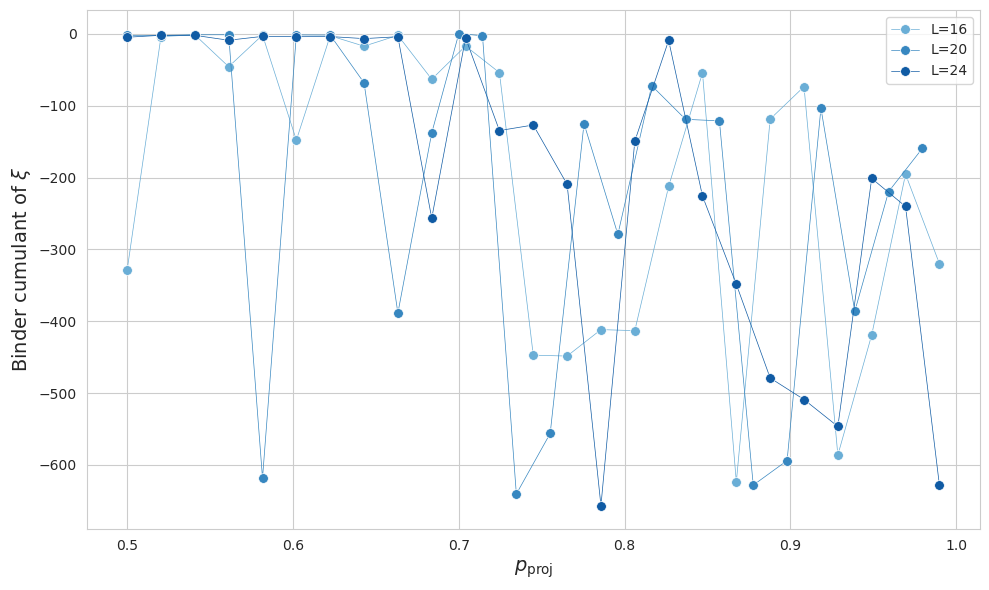

,,observations,estimator
p,L,,
0.500000,12,"[1.3862943611198906, 1.3862943611198906, 2.772...",0.479439
0.510204,12,"[1.3862943611198906, 1.791759469228055, 2.5649...",0.464241
0.520408,12,"[0.6931471805599453, 2.0794415416798357, 1.609...",0.468275
0.530612,12,"[0.6931471805599453, 2.0794415416798357, 1.609...",0.451425
0.540816,12,"[0.6931471805599453, 2.0794415416798357, 1.945...",0.444741


In [ ]:
df_bc_corrlen = df_obs_from_sv_arr(data_dict, corr_len, binder_cumulant)
plot_ensemble_metric(df_bc_corrlen, r'$p_{\mathrm{proj}}$', r'Binder cumulant of $\xi$', L_list=[16, 20, 24])
df_s0.head()

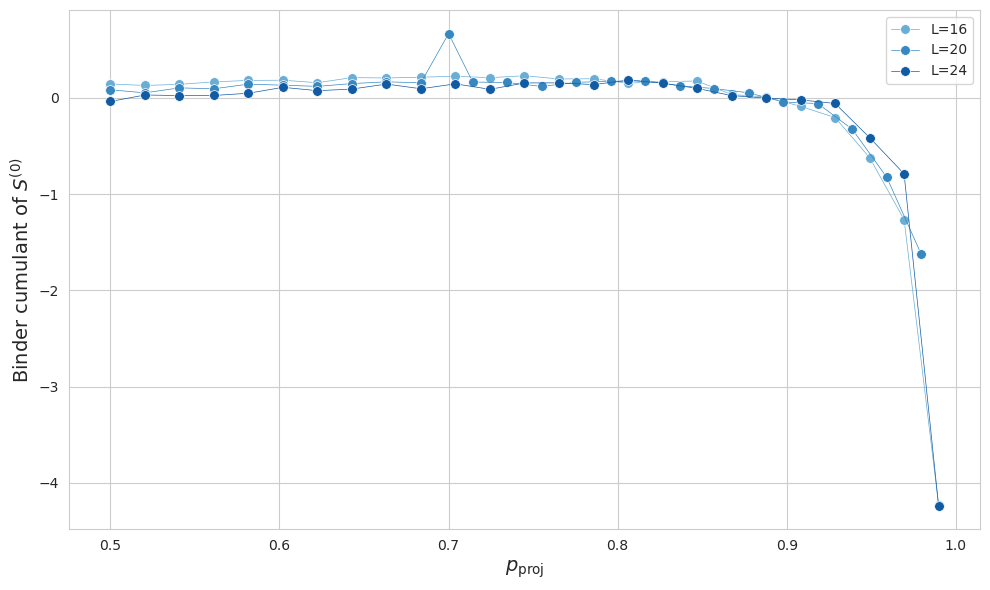

In [28]:
plot_ensemble_metric(df_s0, r'$p_{\mathrm{proj}}$', r'Binder cumulant of $S^{(0)}$', L_list=[16, 20, 24])

/home/ty296/.conda/envs/scicomp/lib/python3.8/site-packages/scipy/stats/_stats_mstats_common.py:181: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm
/home/ty296/.conda/envs/scicomp/lib/python3.8/site-packages/scipy/stats/_stats_mstats_common.py:195: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/home/ty296/.conda/envs/scicomp/lib/python3.8/site-packages/scipy/stats/_stats_mstats_common.py:198: RuntimeWarning: invalid value encountered in scalar divide
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)
/home/ty296/.conda/envs/scicomp/lib/python3.8/site-packages/scipy/stats/_stats_mstats_common.py:181: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm
/home/ty296/.conda/envs/scicomp/lib/python3.8/site-packages/scipy/stats/_stats_mstats_common.py:195: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY

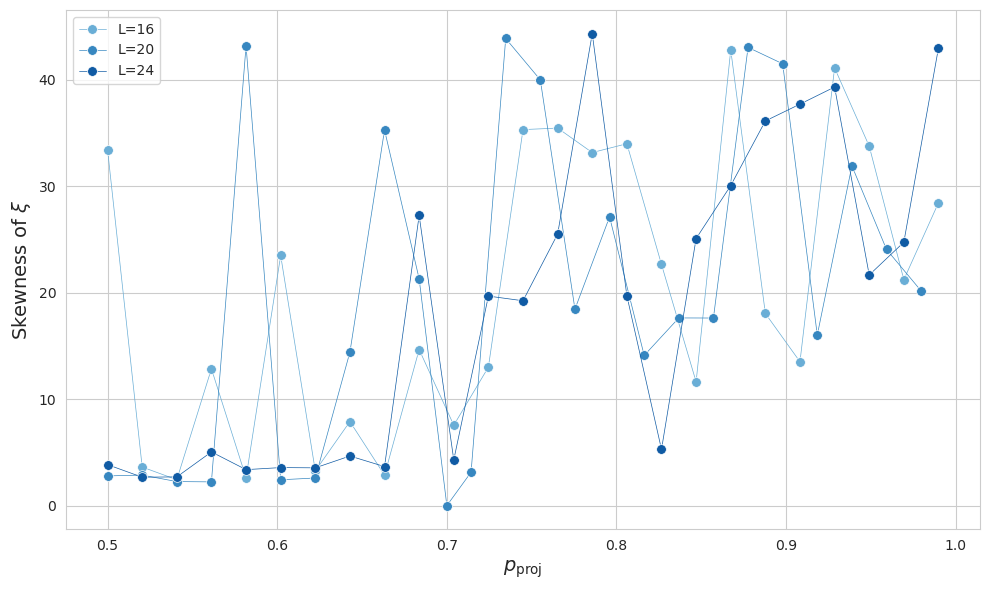

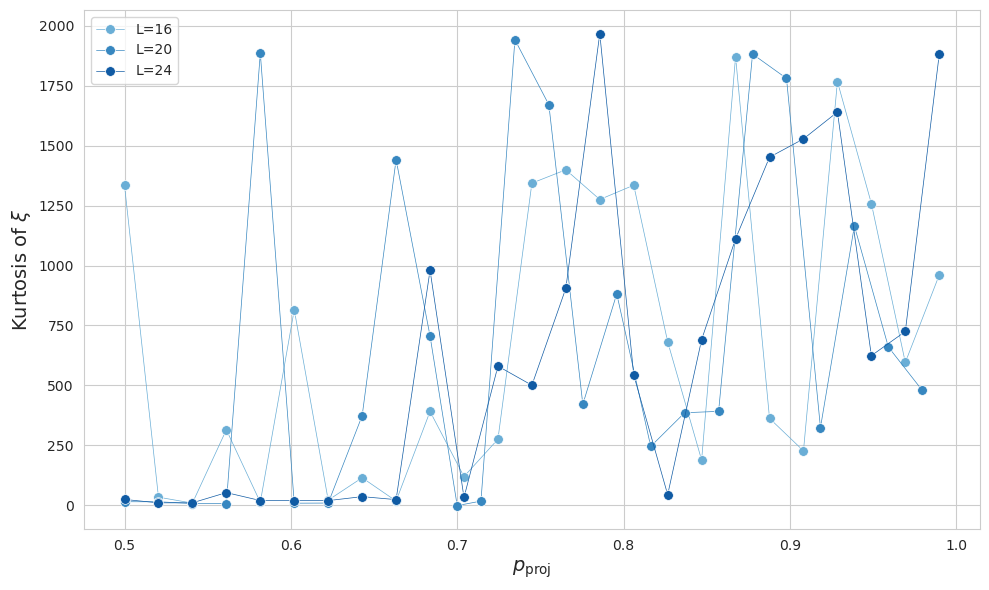

In [33]:
from scipy.stats import skew, kurtosis
df_skewness = df_obs_from_sv_arr(data_dict, corr_len, skew)
df_kurtosis = df_obs_from_sv_arr(data_dict, corr_len, kurtosis)
plot_ensemble_metric(df_skewness, r'$p_{\mathrm{proj}}$', r'Skewness of $\xi$', L_list=[16, 20, 24])
plot_ensemble_metric(df_kurtosis, r'$p_{\mathrm{proj}}$', r'Kurtosis of $\xi$', L_list=[16, 20, 24])


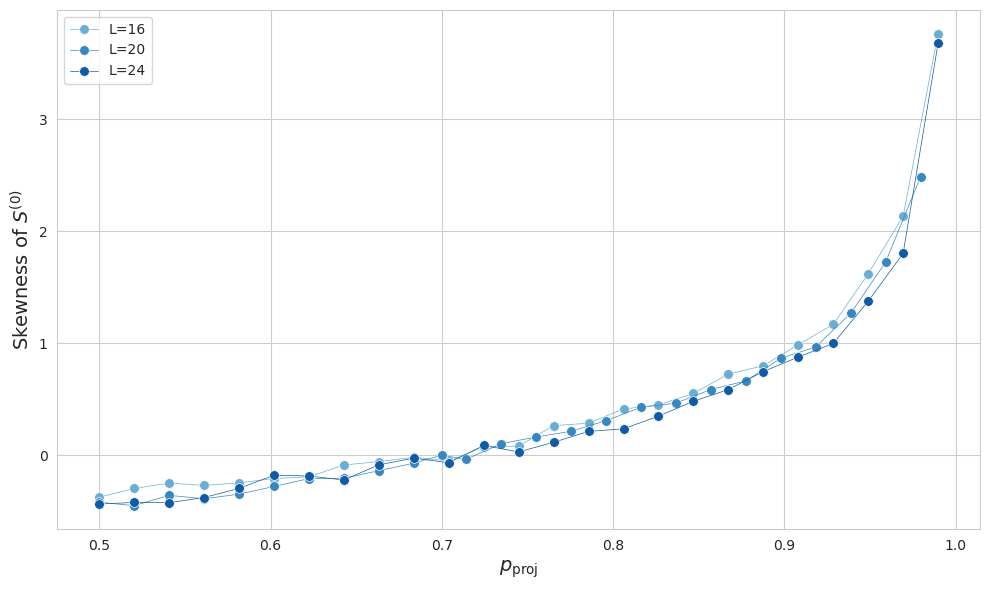

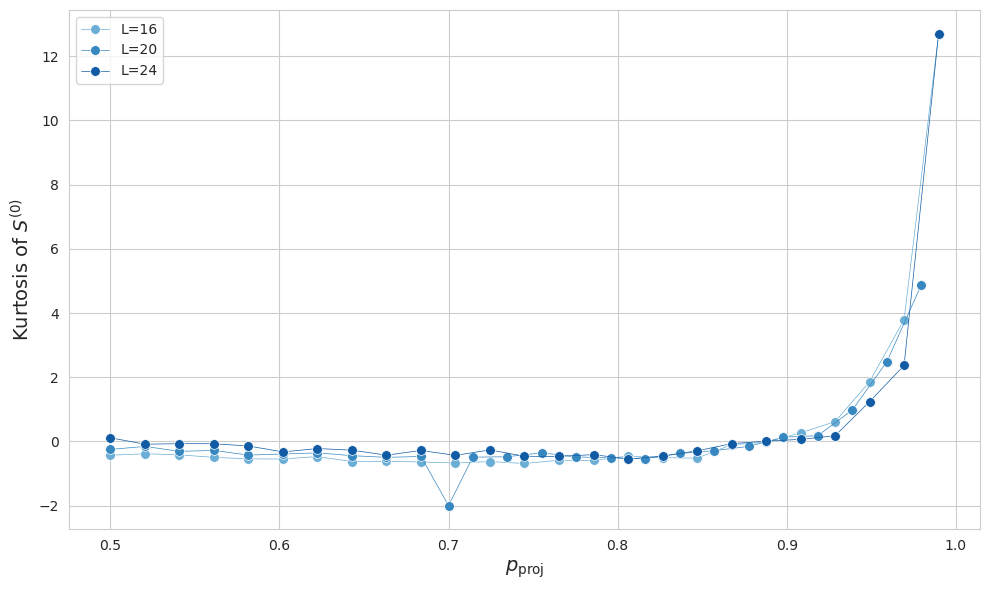

In [34]:
from scipy.stats import skew, kurtosis
df_skewness = df_obs_from_sv_arr(data_dict, s0, skew)
df_kurtosis = df_obs_from_sv_arr(data_dict, s0, kurtosis)
plot_ensemble_metric(df_skewness, r'$p_{\mathrm{proj}}$', r'Skewness of $S^{(0)}$', L_list=[16, 20, 24])
plot_ensemble_metric(df_kurtosis, r'$p_{\mathrm{proj}}$', r'Kurtosis of $S^{(0)}$', L_list=[16, 20, 24])


In [29]:
# Make sure "FSS" is in the sys.path so its modules can be imported from anywhere
import sys
import os

fss_path = os.path.abspath(os.path.join(os.getcwd(), "FSS"))
if fss_path not in sys.path:
    sys.path.insert(0, fss_path)
# from DataCollapse import *
from src.fss.data_collapse import DataCollapse

dc=DataCollapse(df_s0, p_='p',L_='L',params={},p_range=[0.7, 0.8],)

In [30]:
dc.datacollapse(p_c=0.8,nu=0.75,beta=0.0,p_c_vary=True,beta_vary=True,nu_vary=True)

/home/ty296/.conda/envs/scicomp/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/home/ty296/.conda/envs/scicomp/lib/python3.8/site-packages/lmfit/printfuncs.py:393: RuntimeWarning: divide by zero encountered in scalar divide
  spercent = f'({abs(par.stderr/par.value):.2%})'


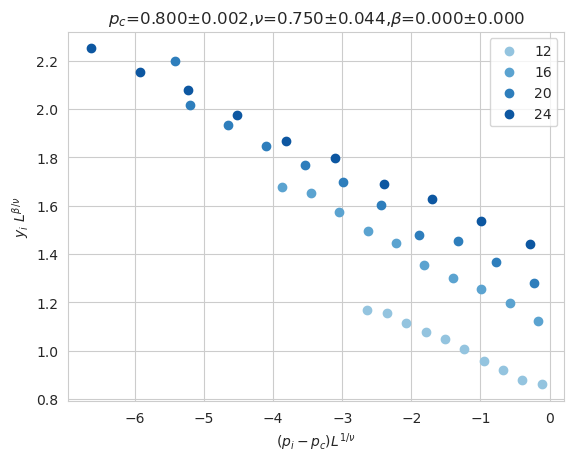

In [31]:
dc.plot_data_collapse()

Normal: μ=1.085, σ=0.545
Lognormal: shape=0.489, scale=0.965


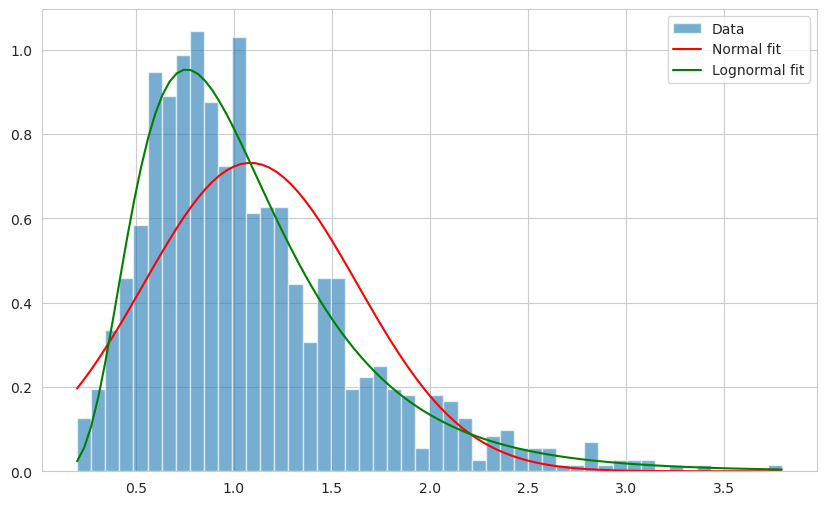

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Example: generate some sample data (replace with your actual data)
data = np.random.lognormal(mean=0, sigma=0.5, size=1000)

# Fit to normal distribution
mu_norm, std_norm = stats.norm.fit(data)
print(f"Normal: μ={mu_norm:.3f}, σ={std_norm:.3f}")

# Fit to lognormal distribution
shape, loc, scale = stats.lognorm.fit(data, floc=0)  # floc=0 fixes location at 0
print(f"Lognormal: shape={shape:.3f}, scale={scale:.3f}")

# Visualize the fits
x = np.linspace(data.min(), data.max(), 100)
plt.figure(figsize=(10, 6))
plt.hist(data, bins=50, density=True, alpha=0.6, label='Data')
plt.plot(x, stats.norm.pdf(x, mu_norm, std_norm), 'r-', label='Normal fit')
plt.plot(x, stats.lognorm.pdf(x, shape, loc, scale), 'g-', label='Lognormal fit')
plt.legend()
plt.show()

In [16]:
# Kolmogorov-Smirnov test (lower is better)
ks_norm = stats.kstest(data, 'norm', args=(mu_norm, std_norm))
ks_lognorm = stats.kstest(data, 'lognorm', args=(shape, loc, scale))

print(f"Normal K-S statistic: {ks_norm.statistic:.4f}, p-value: {ks_norm.pvalue:.4f}")
print(f"Lognormal K-S statistic: {ks_lognorm.statistic:.4f}, p-value: {ks_lognorm.pvalue:.4f}")

# Or use AIC/BIC for model comparison

Normal K-S statistic: 0.1079, p-value: 0.0000
Lognormal K-S statistic: 0.0144, p-value: 0.9841


In [17]:
# from scipy.stats import linregress
# from scipy.stats import skew

# # plot the distribution of len(sv_arr)
# skew_lst = []
# p_proj_lst = []
# for key in data_dict.keys():
#     L, p_proj = key
#     if L == 24:
#         p_proj_lst.append(p_proj)
#         cxi_lst = []
#         r_squared_lst = []
#         fig, (ax, bx) = plt.subplots(1, 2, figsize=(10, 4))        
#         for sv_arr in data_dict[key]:
#             cxi, r_squared = corr_len(sv_arr)
#             cxi_lst.append(cxi)
#             r_squared_lst.append(r_squared)
#         # cxi_lst = np.clip(cxi_lst, 0, 200)
#         mean_cxi = np.mean(cxi_lst)
#         median_cxi = np.median(cxi_lst)
#         b_cumulant = binder_cumulant(cxi_lst)
#         var_cxi = np.var(cxi_lst)
#         skew_lst.append(abs(median_cxi - mean_cxi))
#         # compare mean and var to see if it is Poisson distributed
#         print(f"mean={mean_cxi:.2f}, var={var_cxi:.2f}")
#         ax.hist(cxi_lst, bins=np.arange(0, 200, 1))
#         ax.axvline(mean_cxi, color='red', linestyle='--', label=f'mean={mean_cxi:.2f}')
#         ax.axvline(median_cxi, color='green', linestyle='--', label=f'median={median_cxi:.2f}')
#         ax.axvline(b_cumulant, color='blue', linestyle='--', label=f'binder cumulant={b_cumulant:.2f}')
#         ax.legend()
#         bx.hist(r_squared_lst, bins=np.arange(0, 2, 0.1))
#         ax.set_xlabel(r"$\xi$")
#         bx.set_xlabel(r"$R^2$")
#         ax.set_ylabel(r"number of samples")
#         bx.set_ylabel(r"number of samples")
#         ax.set_title(f"L={L}, p_proj={p_proj:.3f}, p_ctrl=0.4")
#         # plt.savefig(f"L24_corrleng_distr/L24_pproj{p_proj}.png")
#         # plt.show()
#         # plt.close()

In [ ]:
# import numpy as np
# from collections import defaultdict

# s0_dict = defaultdict(list)
# threshold = 1e-14

# with h5py.File(combined_sv_filename, 'r') as f:
#     for key in tqdm.tqdm(f.keys()):
#         # Read attributes once
#         attrs = f[key].attrs
#         L, p_proj = attrs['L'], attrs['p_proj']
        
#         # Don't load entire array - just count elements above threshold
#         dataset = f[key]
#         count = np.sum(dataset[:] > threshold)
#         s0 = np.log(count)
        
#         # defaultdict eliminates the key check
#         s0_dict[(p_proj, L)].append(s0)

 27%|██▋       | 105707/394709 [01:08<03:07, 1538.39it/s]


KeyboardInterrupt: 

In [ ]:
# for key in s0_dict.keys():
#     s0_arr = np.array(s0_dict[key])
#     s0_arr = -s0_arr
#     s0_dict[key] = s0_arr

In [ ]:
# import pandas as pd
# df = output_df(s0_dict)

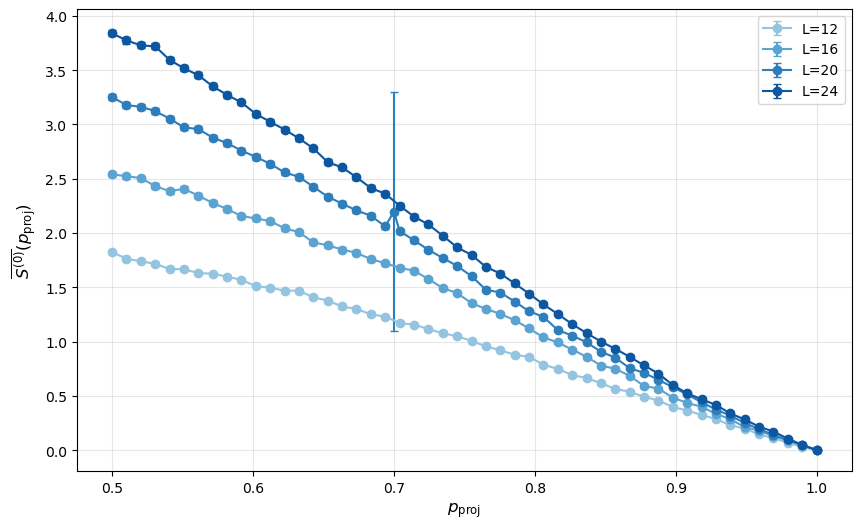

In [ ]:
# import matplotlib.pyplot as plt
# # Plot estimator vs p for different L with same color scheme as data_collapse.py
# fig, ax = plt.subplots(figsize=(10, 6))

# L_list = df.index.get_level_values('L').unique().sort_values().values
# color_iter = iter(plt.cm.Blues(0.4+0.6*(i/L_list.shape[0])) for i in range(L_list.shape[0]))

# for L in L_list:
#     color = next(color_iter)
#     df_L = df.xs(key=L, level='L').sort_index()  # Add sort_index() here
#     p_values = df_L.index.get_level_values('p').values
#     estimator_values = df_L['estimator'].values
#     stderr_values = df_L['standard_error'].values
    
#     ax.errorbar(p_values, estimator_values, yerr=stderr_values, 
#                 fmt='o-', color=color, label=f'L={L}', capsize=3, markersize=6)

# ax.set_xlabel(r'$p_{\mathrm{proj}}$', fontsize=12)
# ax.set_ylabel(r'$\overline{S^{(0)}}(p_{\mathrm{proj}})$', fontsize=12)
# ax.legend()
# ax.grid(True, alpha=0.3)
# # ax.set_ylim()
# # plt.tight_layout()
# plt.show()

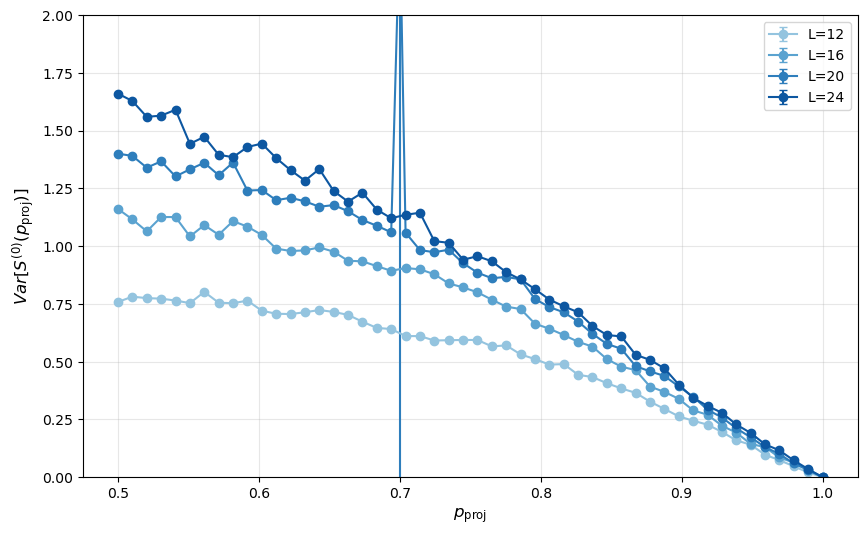

In [ ]:
# import matplotlib.pyplot as plt
# # Plot estimator vs p for different L with same color scheme as data_collapse.py
# fig, ax = plt.subplots(figsize=(10, 6))

# L_list = df.index.get_level_values('L').unique().sort_values().values
# color_iter = iter(plt.cm.Blues(0.4+0.6*(i/L_list.shape[0])) for i in range(L_list.shape[0]))

# for L in L_list:
#     color = next(color_iter)
#     df_L = df.xs(key=L, level='L').sort_index()  # Add sort_index() here
#     p_values = df_L.index.get_level_values('p').values
#     estimator_values = df_L['variance'].values
#     stderr_values = df_L['standard_error_of_variance'].values
    
#     ax.errorbar(p_values, estimator_values, yerr=stderr_values, 
#                 fmt='o-', color=color, label=f'L={L}', capsize=3, markersize=6)

# ax.set_xlabel(r'$p_{\mathrm{proj}}$', fontsize=12)
# ax.set_ylabel(r'$Var[S^{(0)}(p_{\mathrm{proj}})]$', fontsize=12)
# ax.legend()
# ax.grid(True, alpha=0.3)
# ax.set_ylim(0, 2)
# # plt.tight_layout()
# plt.show()